In [3]:
# add local src to path for imports
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'src'))

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from utils.io_utils import load
from utils.viz import preview


# 0 Plot Functions

In [88]:
CMAP = 'bwr_r'  # red = negative, white = 0, blue = positive
HALF = LinearSegmentedColormap.from_list('bwr_r_hi', plt.get_cmap(CMAP)(np.linspace(0.5, 1.0, 256)))
PHASES = ['raw', 'unwrapped', 'trig']

def load_fft(df, sample_id=None, position_id=None, speaker=None):
    if sample_id is not None:
        row = df[df['sample_id'] == sample_id].iloc[0]
    else:
        row = df[(df['position_id'] == position_id) & (df['speaker'] == speaker)].iloc[0]
    with np.load(row['raw_fft_path']) as z:
        fft, freqs = z['fft'], z['freqs']  # (1, L, F, C), (F,)
    return fft[0], freqs, row['sample_id']  # (L, F, C)

def select_fft(fft, laser_idx=55, xy_idx=0):
    # compute |FFT|
    if len(fft.shape) == 3: # multiple lasers, both xy
        fft = fft[..., xy_idx]
        assert laser_idx in ['all', 'avg'] + list(range(fft.shape[0])), f'laser_idx must be one of ["all", "avg"] + [0, ..., {fft.shape[0]-1}]'
        fft = fft if laser_idx == 'all' else fft.mean(0) if laser_idx == 'avg' else fft[laser_idx]
    else:
        laser_idx, xy_idx = None, None
    return fft, laser_idx, xy_idx

def plot_shift(shift, sample_id=None, laser_idx=55, xy_idx=0, ax=None, title=None):
    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))

    title = (title + " " if title is not None else "") + "Shift"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'laser={laser_idx}' if laser_idx is not None else ''
        if xy_idx is not None: label += f'  {"xy"[xy_idx]}'

    if laser_idx == 'all': # plot heatmap
        im = ax.imshow(shift, aspect='auto', origin='lower', cmap=CMAP, vmin=-1, vmax=1, extent=[0, shift.shape[1], 0, len(shift)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=r'$\Delta$ [m]')
    else:
        ax.plot(shift, color='tab:green')
        ax.set_ylabel(r'$\Delta$ [m]')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(0, shift.shape[0])
    if shift.ndim != 3: # (100 lasers, 2500 frames, 2 xy)
        xy_idx, laser_idx = None, None

    if label is not None: ax.legend()
    # return ax

def plot_mag(fft, freqs, sample_id=None, laser_idx=55, xy_idx=0, ax=None, log=True, title=None, label=None):
    # compute |FFT|
    fft, laser_idx, xy_idx = select_fft(fft, laser_idx=laser_idx, xy_idx=xy_idx)
    mag = np.abs(fft)

    if log: mag = np.log(mag)

    title = (title + " " if title is not None else "") + "FFT Magnitude"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'laser={laser_idx}' if laser_idx is not None else ''
        if xy_idx is not None: label += f'  {"xy"[xy_idx]}'

    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))
    if laser_idx == 'all': # plot as heatmap
        im = ax.imshow(mag, aspect='auto', origin='lower', cmap='Blues', vmin=0, vmax=mag.max(), extent=[freqs[0], freqs[-1], 0, len(mag)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=label)
    else:
        ax.plot(freqs, mag, color='tab:blue', label=label)
        ax.set_ylabel(label)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(freqs[0], freqs[-1])

    if label is not None: ax.legend()
    # return ax

def plot_phase(fft, freqs, sample_id=None, laser_idx=55, xy_idx=0, mode='trig', ax=None, title=None, label=None):
    # compute phase(FFT)
    fft, laser_idx, xy_idx = select_fft(fft, laser_idx=laser_idx, xy_idx=xy_idx)
    phase = np.angle(fft)

    title = (title + " " if title is not None else "") + "FFT Phase"
    if sample_id is not None: title += f' {sample_id}'
    ax.set_title(title)

    if label is None:
        label = f'laser={laser_idx}' if laser_idx is not None else ''
    if xy_idx is not None: label += f'  {"xy"[xy_idx]}'


    # select mode
    if mode == 'raw':
        phase, ylabel, vlim = phase, r'$\theta$ [rad]', (-np.pi, np.pi)
    elif mode == 'unwrapped':
        phase, ylabel, vlim = np.unwrap(phase, axis=-1), r'unwrapped $\theta$ [rad]', None
    elif mode == 'trig': # only use cos, not sin
        phase, ylabel, vlim = np.cos(phase), r'$\cos\theta$', (-1, 1)
    else:
        raise ValueError(f'Unknown mode: {mode}. Must be one of {PHASES}')
    if vlim is None: vlim = (phase.min(), phase.max())

    if ax is None: fig, ax = plt.subplots(figsize=(16, 4))
    if laser_idx == 'all': # plot heatmap
        im = ax.imshow(phase, aspect='auto', origin='lower', cmap=CMAP, vmin=vlim[0], vmax=vlim[1], extent=[freqs[0], freqs[-1], 0, len(phase)])
        ax.set_ylabel('Laser')
        ax.set_xlabel('Frequency (Hz)')
        ax.figure.colorbar(im, ax=ax, label=ylabel)
    else:
        ax.plot(freqs, phase, color='tab:orange', label=label)
        ax.set_ylim(vlim[0] * 1.1, vlim[1] * 1.1)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_xlim(freqs[0], freqs[-1])

    if label is not None: ax.legend()

    # return ax

# 1 Original Audio

In [89]:
AUDIO_PATH = '/home/ethantu/workspace/good-vibrations/data/audio/chirp_50_1000_1.0sec/audio.wav'

In [90]:
audio, fs = load(AUDIO_PATH)
audio.shape, fs

((52920,), 44100)

In [91]:
preview((audio, fs), 'audio')

UnboundLocalError: cannot access local variable 'label' where it is not associated with a value

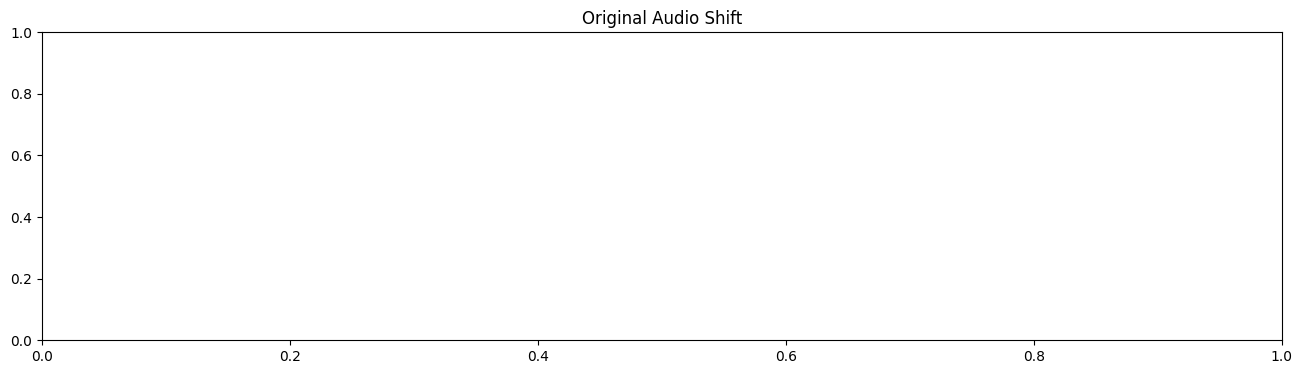

In [92]:
plot_shift(audio, title='Original Audio')

In [93]:
# compute fft, freqs
fft = np.fft.rfft(audio).astype(np.complex64)
freqs = np.fft.rfftfreq(len(audio), d=1.0 / fs)
# rfft returns freqs from 0 to fs/2 (up until Nyquist), so we mask out all unused freqs
mask = (freqs >= 50) & (freqs <= 1000)
fft, freqs = fft[..., mask], freqs[mask]

fft.shape, freqs.shape

((1141,), (1141,))

/tmp/ipykernel_718460/914604675.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()
/tmp/ipykernel_718460/914604675.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


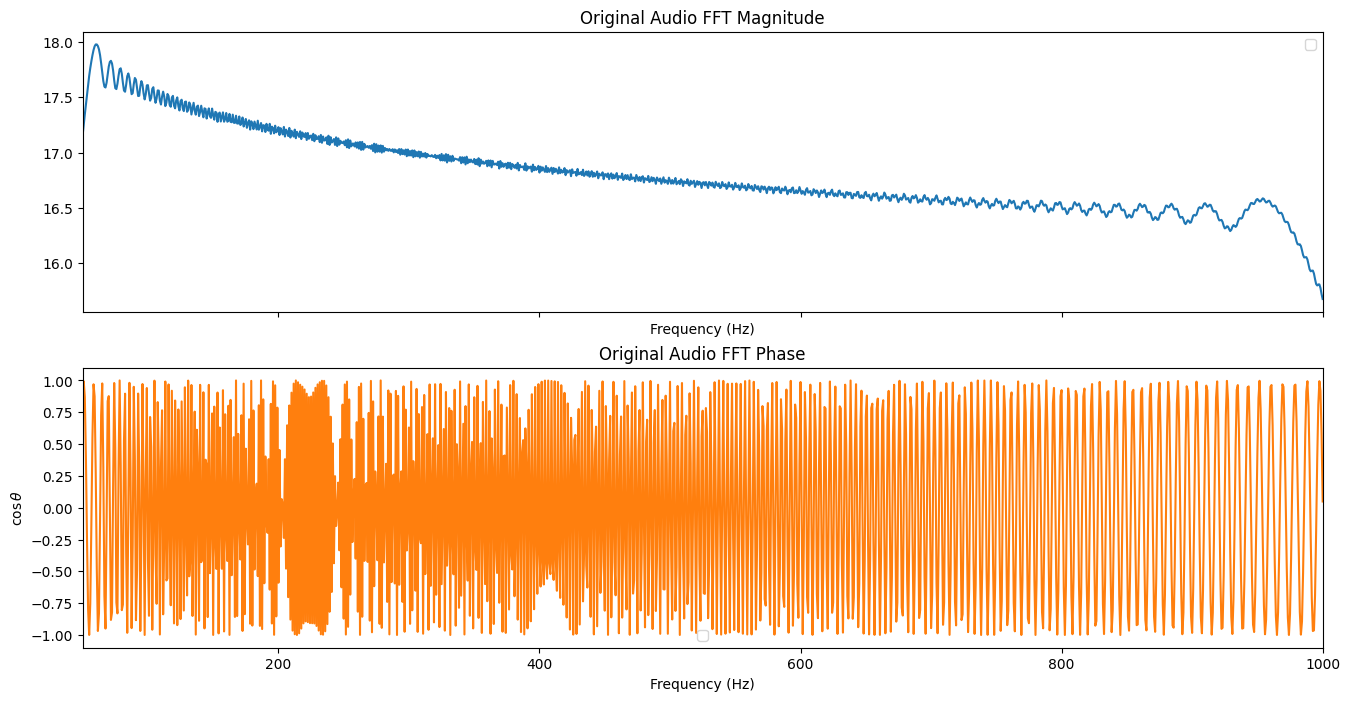

In [94]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
plot_mag(fft, freqs, ax=ax[0], title='Original Audio')
plot_phase(fft, freqs, ax=ax[1], title='Original Audio')

# ax[0].set_xlim(100, 150)
# ax[1].set_xlim(100, 150)

# 2 Load the gastronorm dataset

In [95]:
REPO = Path('/home/ethantu/workspace/good-vibrations')
EXP = REPO / 'experiments/31_07_2026_gastronorm_exp1'

RAW_FFT_REL = 'vibration/04_fft.npz'                 # complex64, (1, L, F, C)
RAW_SHIFTS_REL = 'vibration/02_raw_shifts.npy'       # float32,  (L, T, C)     <- plot_shifts wants this
CLEAN_SHIFTS_REL = 'vibration/03_clean_shifts.npy'   # float64,  (1, L, T, C)

In [96]:
def load_gastronorm(exp_dir: Path = EXP, mds_dir: Path | None = None) -> pd.DataFrame:
    """Return one row per sample in the MDS index, with paths to the raw artifacts."""
    if mds_dir is None:
        mds_dir = sorted(exp_dir.glob('mds/*/metadata.jsonl'))[0].parent
    index = [json.loads(l) for l in (mds_dir / 'metadata.jsonl').read_text().strip().splitlines() if l]
    df = pd.DataFrame(index)

    samples = exp_dir / 'samples'
    df['sample_dir'] = df['sample_id'].map(lambda s: samples / s)
    for col, rel in [('raw_fft_path', RAW_FFT_REL),
                     ('raw_shifts_path', RAW_SHIFTS_REL),
                     ('clean_shifts_path', CLEAN_SHIFTS_REL)]:
        df[col] = df['sample_dir'].map(lambda d, rel=rel: d / rel)
        df[col.replace('_path', '_exists')] = df[col].map(lambda p: p.exists())
        df['sample_id'] = df['sample_id'].astype(int)
        df['position_id'] = df['position_id'].astype(int)
        df['speaker'] = df['speaker'].astype(int)

    return df

df = load_gastronorm()
print(f'{len(df)} rows x {df.shape[1]} cols')
df[['sample_id', 'layout', 'speaker', 'position_id', 'n_objects', 'avg_com', 'raw_fft_path', 'raw_shifts_path']].head(8)

3007 rows x 44 cols


,sample_id,layout,speaker,position_id,n_objects,avg_com,raw_fft_path,raw_shifts_path
0,10,empty-box,2,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
1,11,empty-box,3,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
2,12,empty-box,4,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
3,13,empty-box,5,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
4,14,empty-box,6,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
5,15,empty-box,7,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
6,16,empty-box,8,2,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
7,17,empty-box,1,3,0,[-1 -1],/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...


# 3 Inspect Recovered FFTs

In [97]:
sample_id = 500
laser_idx = 'all'

fft, freqs, sample_id = load_fft(df, sample_id)
fft.shape, freqs.shape

((100, 1235, 2), (1235,))

/tmp/ipykernel_718460/914604675.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()
/tmp/ipykernel_718460/914604675.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if label is not None: ax.legend()


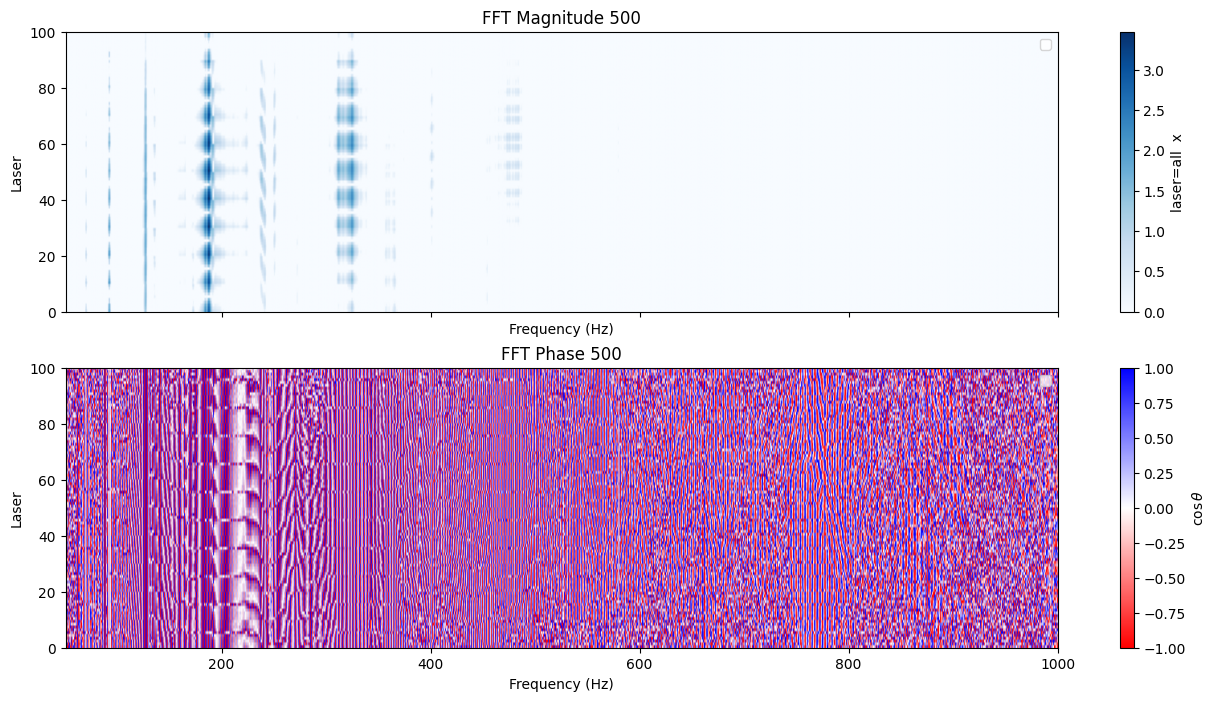

In [98]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
plot_mag(fft, freqs, sample_id, xy_idx=0, laser_idx=laser_idx, ax=axs[0])
plot_phase(fft, freqs, sample_id, xy_idx=0, laser_idx=laser_idx, ax=axs[1])

# axs[0].set_xlim(100, 150)
# axs[1].set_xlim(100, 150)